# Dataquest 2023 Final: TrOCR exploration and fine-tuning on the drug-label crops (Colab)

In [ ]:
!nvidia-smi

Sat Oct  7 00:58:33 2023       
+-----------------------------------------------------------------------------+
| NVIDIA-SMI 450.156.00   Driver Version: 450.156.00   CUDA Version: 11.5     |
|-------------------------------+----------------------+----------------------+
| GPU  Name        Persistence-M| Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp  Perf  Pwr:Usage/Cap|         Memory-Usage | GPU-Util  Compute M. |
|                               |                      |               MIG M. |
|===============================+======================+======================|
|   0  A100-SXM4-40GB      On   | 00000000:07:00.0 Off |                    0 |
| N/A   28C    P0    61W / 400W |  31363MiB / 40537MiB |      0%      Default |
|                               |                      |             Disabled |
+-------------------------------+----------------------+----------------------+
|   1  A100-SXM4-40GB      On   | 00000000:0F:00.0 Off |                    0 |
| N/A   

In [ ]:
import os

os.environ['CUDA_VISIBLE_DEVICES'] = '0'

DATA_DIR = "../data/dataset2"
MODEL_DIR = "../models/prep_lprinted"

In [ ]:
# check cuda version
!nvcc --version

nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2021 NVIDIA Corporation
Built on Mon_Sep_13_19:13:29_PDT_2021
Cuda compilation tools, release 11.5, V11.5.50
Build cuda_11.5.r11.5/compiler.30411180_0


In [ ]:
# check tensorflow version
import tensorflow as tf
print(tf.__version__)

2.6.0


In [ ]:
# install pytorch that matches cuda version
!pip install torch==1.10.0+cu113 torchvision==0.11.1+cu113 torchaudio==0.10.0 -f https://download.pytorch.org/whl/torch_stable.html

Looking in links: https://download.pytorch.org/whl/torch_stable.html
You should consider upgrading via the '/usr/bin/python -m pip install --upgrade pip' command.


In [23]:
!pip install transformers
!pip install evaluate
!pip install accelerate
!pip install jiwer

In [2]:
# check cuda
import torch
print(torch.cuda.is_available())

# check tf gpu list
import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))

True
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [4]:
from transformers import TrOCRProcessor, VisionEncoderDecoderModel
from PIL import Image
import requests

# load image from the IAM database (actually this model is meant to be used on printed text)
url = 'https://fki.tic.heia-fr.ch/static/img/a01-122-02-00.jpg'
image = Image.open(requests.get(url, stream=True).raw).convert("RGB")

processor = TrOCRProcessor.from_pretrained('microsoft/trocr-base-printed')
model = VisionEncoderDecoderModel.from_pretrained('microsoft/trocr-large-printed')
pixel_values = processor(images=image, return_tensors="pt").pixel_values

generated_ids = model.generate(pixel_values)
generated_text = processor.batch_decode(generated_ids, skip_special_tokens=True)[0]

Could not find image processor class in the image processor config or the model config. Loading based on pattern matching with the model's feature extractor configuration.


Some weights of VisionEncoderDecoderModel were not initialized from the model checkpoint at microsoft/trocr-large-printed and are newly initialized: ['encoder.pooler.dense.bias', 'encoder.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


/usr/local/lib/python3.10/dist-packages/transformers/generation/utils.py:1260: UserWarning: Using the model-agnostic default `max_length` (=20) to control the generation length. We recommend setting `max_new_tokens` to control the maximum length of the generation.
  warnings.warn(


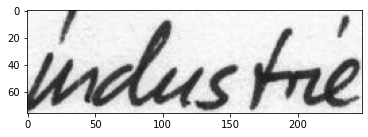

MALUSTHE


In [ ]:
import matplotlib.pyplot as plt
plt.imshow(image)
plt.show()
print(generated_text)

In [ ]:
from transformers import TrOCRProcessor, VisionEncoderDecoderModel
from PIL import Image
import requests

# load image from the IAM database
url = 'https://fki.tic.heia-fr.ch/static/img/a01-122-02-00.jpg'
image = Image.open(requests.get(url, stream=True).raw).convert("RGB")

processor = TrOCRProcessor.from_pretrained('microsoft/trocr-base-handwritten')
model = VisionEncoderDecoderModel.from_pretrained('microsoft/trocr-base-handwritten')
pixel_values = processor(images=image, return_tensors="pt").pixel_values

generated_ids = model.generate(pixel_values)
generated_text = processor.batch_decode(generated_ids, skip_special_tokens=True)[0]

Could not find image processor class in the image processor config or the model config. Loading based on pattern matching with the model's feature extractor configuration.


Some weights of VisionEncoderDecoderModel were not initialized from the model checkpoint at microsoft/trocr-base-handwritten and are newly initialized: ['encoder.pooler.dense.bias', 'encoder.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


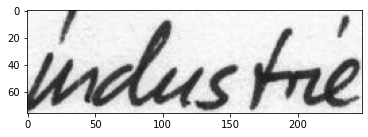

indus the


In [ ]:
import matplotlib.pyplot as plt
plt.imshow(image)
plt.show()
print(generated_text)

In [ ]:
from transformers import AutoImageProcessor, DeformableDetrForObjectDetection
import torch
from PIL import Image
import requests

url = "http://images.cocodataset.org/val2017/000000039769.jpg"
image = Image.open(requests.get(url, stream=True).raw)

processor = AutoImageProcessor.from_pretrained("SenseTime/deformable-detr")
model = DeformableDetrForObjectDetection.from_pretrained("SenseTime/deformable-detr",
                                                         # with_box_refine=True,
                                                         # two_stage=True,
                                                         )

inputs = processor(images=image, return_tensors="pt")
outputs = model(**inputs)

# convert outputs (bounding boxes and class logits) to COCO API
# let's only keep detections with score > 0.7
target_sizes = torch.tensor([image.size[::-1]])
results = processor.post_process_object_detection(outputs, target_sizes=target_sizes, threshold=0.7)[0]

for score, label, box in zip(results["scores"], results["labels"], results["boxes"]):
    box = [round(i, 2) for i in box.tolist()]
    print(
        f"Detected {model.config.id2label[label.item()]} with confidence "
        f"{round(score.item(), 3)} at location {box}"
    )

Extension horovod.torch has not been built: /usr/local/lib/python3.8/dist-packages/horovod/torch/mpi_lib/_mpi_lib.cpython-38-x86_64-linux-gnu.so not found
If this is not expected, reinstall Horovod with HOROVOD_WITH_PYTORCH=1 to debug the build error.
Warning! MPI libs are missing, but python applications are still avaiable.


Could not find image processor class in the image processor config or the model config. Loading based on pattern matching with the model's feature extractor configuration.
The `max_size` parameter is deprecated and will be removed in v4.26. Please specify in `size['longest_edge'] instead`.
Some weights of the model checkpoint at SenseTime/deformable-detr were not used when initializing DeformableDetrForObjectDetection: ['model.backbone.conv_encoder.model.layer4.0.downsample.1.num_batches_tracked', 'model.backbone.conv_encoder.model.layer1.0.downsample.1.num_batches_tracked', 'model.backbone.conv_encoder.model.layer3.0.downsample.1.num_batches_tracked', 'model.backbone.conv_encoder.model.layer2.0.downsample.1.num_batches_tracked']
- This IS expected if you are initializing DeformableDetrForObjectDetection from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS

Detected cat with confidence 0.8 at location [16.5, 52.84, 318.25, 470.78]
Detected cat with confidence 0.789 at location [342.19, 24.3, 640.02, 372.25]


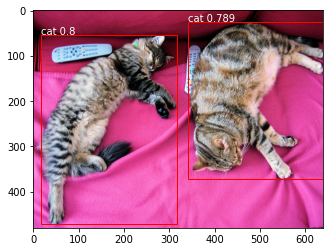

In [ ]:
# plot
import matplotlib.pyplot as plt
import matplotlib.patches as patches

fig, ax = plt.subplots(1)
ax.imshow(image)

for score, label, box in zip(results["scores"], results["labels"], results["boxes"]):
    box = [round(i, 2) for i in box.tolist()]
    rect = patches.Rectangle(
        (box[0], box[1]),
        box[2] - box[0],
        box[3] - box[1],
        linewidth=1,
        edgecolor="r",
        facecolor="none",
    )
    ax.add_patch(rect)
    ax.text(box[0], box[1], f"{model.config.id2label[label.item()]} {round(score.item(), 3)}", color="white")

plt.show()

## Import Dataset

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.notebook import tqdm
import cv2, imutils

from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import (
    TrOCRProcessor,
    VisionEncoderDecoderModel,
    Seq2SeqTrainingArguments,
    Seq2SeqTrainer,
    default_data_collator,
    AdamW,
)
import evaluate
# from datasets import load_metric

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(DEVICE)

cuda


## Load Dataset

In [40]:
train_df = pd.read_csv(f"{DATA_DIR}/train.csv")
train_df['path'] = train_df['path'].str.replace('.png', '.jpg').str.replace('.jpeg', '.jpg')
train_df = train_df.rename(columns={"path": "file_name", "label": "text"})
train_df.text = train_df.text.str.upper()
train_df.head()

<ipython-input-40-b000f6c7a67d>:2: FutureWarning: The default value of regex will change from True to False in a future version.
  train_df['path'] = train_df['path'].str.replace('.png', '.jpg').str.replace('.jpeg', '.jpg')


,file_name,text
0,1.jpg,HOT IN CREAM
1,2.jpg,BYEBYE-FEVER
2,3.jpg,FITBES FORCE
3,4.jpg,TEMPRA PARACETAMOL
4,5.jpg,BIOBAIA INTERLAC


In [41]:
train_df, val_df = train_test_split(train_df, test_size=0.2)
train_df.reset_index(drop=True, inplace=True)
val_df.reset_index(drop=True, inplace=True)
train_df.head()

,file_name,text
0,61.jpg,ALAXAN FR
1,54.jpg,AKURAT
2,84.jpg,ALOPROS 5
3,24.jpg,ACCU-CHEK INSTANT
4,89.jpg,ALTAMED ALCOHOL SWAB


In [42]:
class OCRDataset(Dataset):
    def __init__(self, root_dir, df, processor, max_target_length=128, is_otsu=False):
        self.root_dir = root_dir
        self.df = df
        self.processor = processor
        self.max_target_length = max_target_length

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        # get file name + text
        file_name = self.df['file_name'][idx]
        text = self.df['text'][idx]
        # prepare image (i.e. resize + normalize)
        image = Image.open(self.root_dir + file_name).convert("RGB")
        pixel_values = self.processor(image, return_tensors="pt").pixel_values
        # add labels (input_ids) by encoding the text
        labels = self.processor.tokenizer(text,
                                          padding="max_length",
                                          max_length=self.max_target_length).input_ids
        # important: make sure that PAD tokens are ignored by the loss function
        labels = [label if label != self.processor.tokenizer.pad_token_id else -100 for label in labels]

        encoding = {"pixel_values": pixel_values.squeeze(), "labels": torch.tensor(labels)}
        return encoding

In [43]:
processor = TrOCRProcessor.from_pretrained("microsoft/trocr-base-printed")
train_dataset = OCRDataset(
    root_dir=f"{DATA_DIR}/",
    df=train_df,
    processor=processor,
    is_otsu=True,
)
val_dataset = OCRDataset(
    root_dir=f"{DATA_DIR}/",
    df=val_df,
    processor=processor,
    is_otsu=True,
)

Could not find image processor class in the image processor config or the model config. Loading based on pattern matching with the model's feature extractor configuration.


In [44]:
train_dataloader = DataLoader(train_dataset, batch_size=4, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=4)

In [45]:
print("Number of training examples:", len(train_dataset))
print("Number of validation examples:", len(val_dataset))

Number of training examples: 80
Number of validation examples: 20


In [46]:
encoding = train_dataset[0]
for k, v in encoding.items():
    print(k, v.shape)

pixel_values torch.Size([3, 384, 384])
labels torch.Size([128])


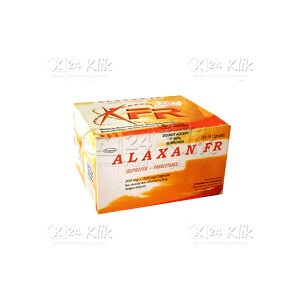

In [47]:
image = Image.open(train_dataset.root_dir + train_df['file_name'][0]).convert("RGB")
image

In [48]:
labels = encoding['labels']
labels[labels == -100] = processor.tokenizer.pad_token_id
label_str = processor.decode(labels, skip_special_tokens=True)
print(label_str)

ALAXAN FR


## Before Finetuning

In [ ]:
model = VisionEncoderDecoderModel.from_pretrained('microsoft/trocr-large-handwritten')

Some weights of VisionEncoderDecoderModel were not initialized from the model checkpoint at microsoft/trocr-large-handwritten and are newly initialized: ['encoder.pooler.dense.bias', 'encoder.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
pixel_values = processor(images=image, return_tensors="pt").pixel_values
generated_ids = model.generate(pixel_values)
generated_text = processor.batch_decode(generated_ids, skip_special_tokens=True)[0]
generated_text

/usr/local/lib/python3.8/dist-packages/transformers/generation/utils.py:1260: UserWarning: Using the model-agnostic default `max_length` (=20) to control the generation length. We recommend setting `max_new_tokens` to control the maximum length of the generation.
  warnings.warn(


'0.'

In [ ]:
model = VisionEncoderDecoderModel.from_pretrained('microsoft/trocr-large-printed')

Some weights of VisionEncoderDecoderModel were not initialized from the model checkpoint at microsoft/trocr-large-printed and are newly initialized: ['encoder.pooler.dense.bias', 'encoder.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
pixel_values = processor(images=image, return_tensors="pt").pixel_values
generated_ids = model.generate(pixel_values)
generated_text = processor.batch_decode(generated_ids, skip_special_tokens=True)[0]
generated_text

'TOTAL'

## Finetuning

In [49]:
model = VisionEncoderDecoderModel.from_pretrained("microsoft/trocr-base-printed")
model.to(DEVICE)

# set special tokens used for creating the decoder_input_ids from the labels
model.config.decoder_start_token_id = processor.tokenizer.cls_token_id
model.config.pad_token_id = processor.tokenizer.pad_token_id
# make sure vocab size is set correctly
model.config.vocab_size = model.config.decoder.vocab_size

# set beam search parameters
model.config.eos_token_id = processor.tokenizer.sep_token_id
model.config.max_length = 64
model.config.early_stopping = True
model.config.no_repeat_ngram_size = 3
model.config.length_penalty = 2.0
model.config.num_beams = 4

Some weights of VisionEncoderDecoderModel were not initialized from the model checkpoint at microsoft/trocr-base-printed and are newly initialized: ['encoder.pooler.dense.bias', 'encoder.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [50]:
cer_metric = evaluate.load("cer")
def compute_metrics(pred):
    labels_ids = pred.label_ids
    pred_ids = pred.predictions

    pred_str = processor.batch_decode(pred_ids, skip_special_tokens=True)
    labels_ids[labels_ids == -100] = processor.tokenizer.pad_token_id
    label_str = processor.batch_decode(labels_ids, skip_special_tokens=True)

    cer = cer_metric.compute(predictions=pred_str, references=label_str)

    return {"cer": cer}

In [56]:
output_dir = MODEL_DIR

training_args = Seq2SeqTrainingArguments(
    predict_with_generate=True,
    # evaluation_strategy="steps",
    evaluation_strategy="epoch",
    logging_strategy="epoch",
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
#     fp16=True,
    overwrite_output_dir=True,
    output_dir=output_dir,
    # logging_steps=2,
    # save_steps=500,
    # eval_steps=200,
    report_to="none",
    num_train_epochs=5,
#     device="cuda",
)

trainer = Seq2SeqTrainer(
    model=model,
    tokenizer=processor.feature_extractor,
    args=training_args,
    compute_metrics=compute_metrics,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator=default_data_collator,
)

import time
train_time = time.time()
trainer.train()
train_time = time.time() - train_time
print("train time (sec)", train_time)

/usr/local/lib/python3.10/dist-packages/transformers/models/trocr/processing_trocr.py:135: FutureWarning: `feature_extractor` is deprecated and will be removed in v5. Use `image_processor` instead.
  warnings.warn(


Epoch,Training Loss,Validation Loss,Cer
1,2.318400,5.172333,0.773333
2,1.667200,4.450727,0.795556
3,0.713200,4.836676,0.755556
4,0.287500,5.093614,0.697778
5,0.173400,4.957584,0.742222


train time (sec) 134.86916518211365


In [57]:
output_dir = MODEL_DIR

In [62]:
pixel_values = processor(images=image, return_tensors="pt").pixel_values
generated_ids = model.generate(pixel_values)
generated_text = processor.batch_decode(generated_ids, skip_special_tokens=True)[0]
generated_text

RuntimeError: ignored

In [70]:
model_ft = VisionEncoderDecoderModel.from_pretrained(MODEL_DIR)

HFValidationError: ignored

In [63]:
output_dir

"<DRIVE_PATH>'s Vault/Dataquest 2023/Final/Preps/models/prep_lprinted"